<a href="https://colab.research.google.com/github/Ferozshah-DS/premium_prediction-regression-project/blob/main/premium_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
from google.colab import files
uploaded = files.upload()

Saving premiums.xlsx to premiums.xlsx


In [6]:
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)

In [7]:
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


In [8]:
df.shape

(50000, 13)

In [9]:
df.isna().sum()

,0
Age,0
Gender,0
Region,0
Marital_status,0
Number Of Dependants,0
BMI_Category,0
Smoking_Status,11
Employment_Status,2
Income_Level,13
Income_Lakhs,0


In [10]:
df.dropna(inplace=True)
df.isna().sum()

,0
Age,0
Gender,0
Region,0
Marital_status,0
Number Of Dependants,0
BMI_Category,0
Smoking_Status,0
Employment_Status,0
Income_Level,0
Income_Lakhs,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#df.drop_duplicates(inplace=True)

In [12]:
df.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,49976.000000,49976.000000,49976.000000,49976.000000
mean,34.591764,1.711842,23.021150,15766.810189
std,15.000378,1.498195,24.221794,8419.995271
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.750000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22273.500000
max,356.000000,5.000000,930.000000,43471.000000


Age cannot be 356 and dependent cannot be negative

In [13]:
df["Number Of Dependants"]=abs(df["Number Of Dependants"])

In [14]:
numeric_col = df.select_dtypes(["float64","int64"])

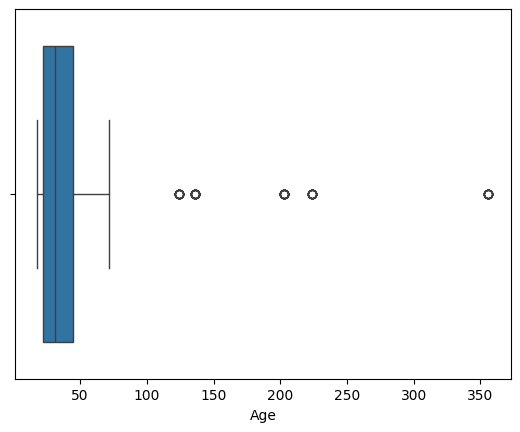

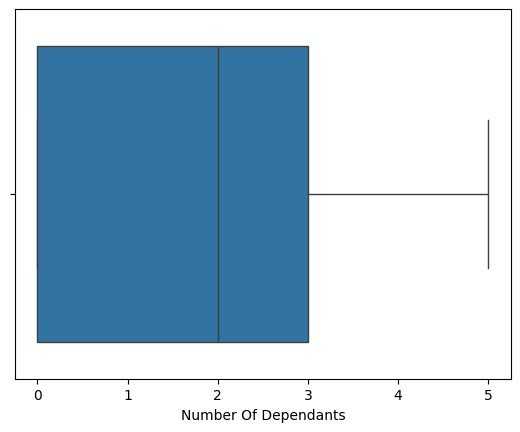

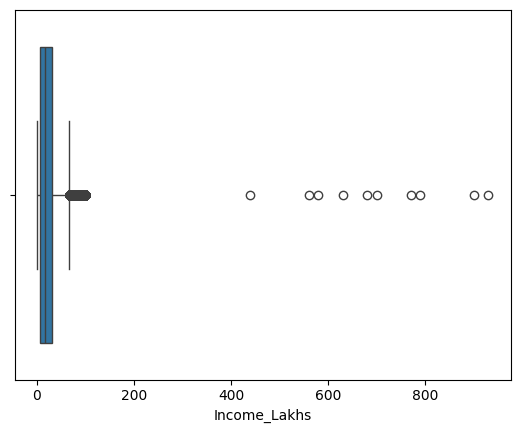

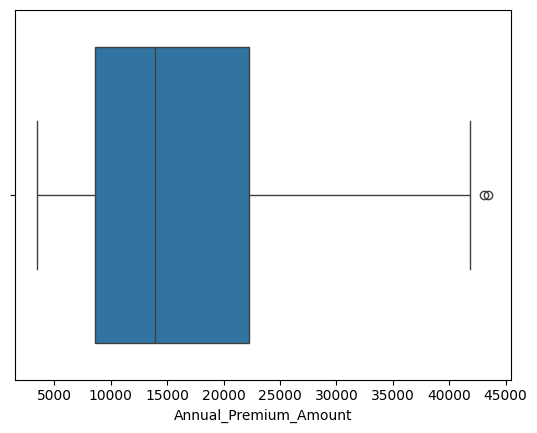

In [15]:
for col in numeric_col:
     sns.boxplot(x=df[col])
     plt.show()

In [16]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [17]:
df1=df[df.Age<=100].copy()
df1.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,49918.000000,49918.000000,49918.000000,49918.000000
mean,34.401839,1.717617,23.025141,15766.589286
std,13.681600,1.492074,24.227912,8419.137327
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22272.000000
max,72.000000,5.000000,930.000000,43471.000000


In [18]:
def get_iqr_bound(col):
    Q1, Q3 = col.quantiles([0.25,0.75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

In [19]:
df1.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [20]:
quantile_threshold = df1["Income_Lakhs"].quantile(0.999)
quantile_threshold

np.float64(100.0)

In [21]:
df2 = df1[df1.Income_Lakhs<=quantile_threshold].copy()

In [22]:
df2.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,49908.000000,49908.000000,49908.000000,49908.000000
mean,34.401579,1.717640,22.889897,15765.739641
std,13.681604,1.492032,22.170699,8418.674061
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22270.500000
max,72.000000,5.000000,100.000000,43471.000000


In [31]:
numerical_col = df2.select_dtypes("int64")

In [32]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49908 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    49908 non-null  int64 
 1   Gender                 49908 non-null  object
 2   Region                 49908 non-null  object
 3   Marital_status         49908 non-null  object
 4   Number Of Dependants   49908 non-null  int64 
 5   BMI_Category           49908 non-null  object
 6   Smoking_Status         49908 non-null  object
 7   Employment_Status      49908 non-null  object
 8   Income_Level           49908 non-null  object
 9   Income_Lakhs           49908 non-null  int64 
 10  Medical History        49908 non-null  object
 11  Insurance_Plan         49908 non-null  object
 12  Annual_Premium_Amount  49908 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 5.3+ MB


In [33]:
numerical_col

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
0,26,0,6,9053
1,29,2,6,16339
2,49,2,20,18164
3,30,3,77,20303
4,18,0,99,13365
...,...,...,...,...
49995,24,0,35,9111
49996,47,2,82,27076
49997,21,0,32,8564
49998,18,2,20,9490


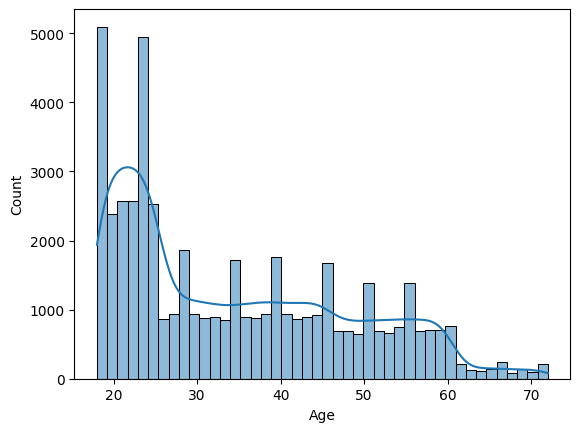

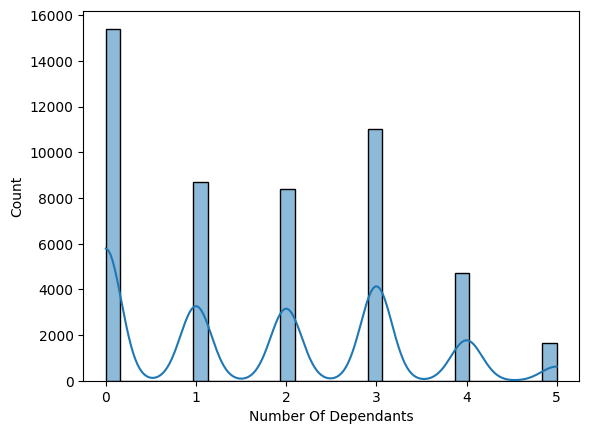

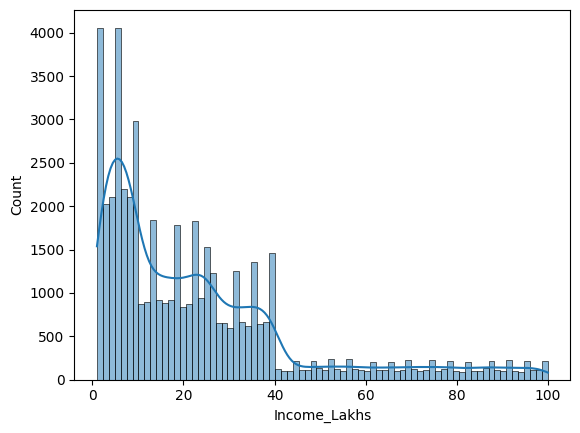

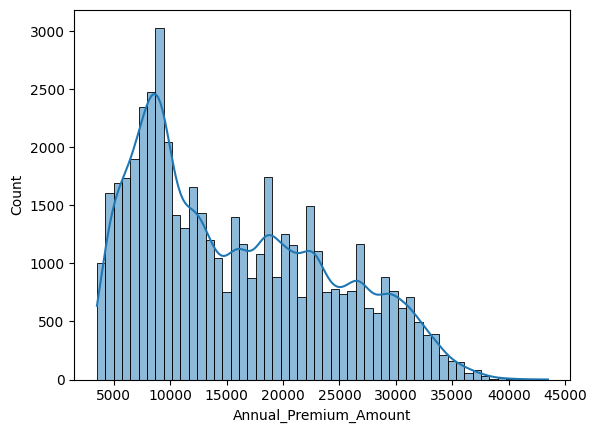

In [34]:
for col in numerical_col:
   sns.histplot(x=df2[col],kde=True)
   plt.show()

In [ ]:
df2.columns

In [ ]:
sns.scatterplot(x=df["Age"],y=def["